In [1]:
using Pkg; #Pkg.add("Symbolics")
#Pkg.add("Groebner")
# Pkg.add("CairoMakie")
# Pkg.add("DifferentialEquations")
# Pkg.add("Optim")
# Pkg.add("SymPy")
# Pkg.add("LinearAlgebra")
ENV["PYTHON"] = "~/miniconda3/envs/forJulia/bin/python"
Pkg.build("PyCall")

    Building Conda ─→ `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/8f06b0cfa4c514c7b9546756dbae91fcfbc92dc9/build.log`
    Building PyCall → `~/.julia/scratchspaces/44cfe95a-1eb2-52ea-b672-e2afdf69b78f/9816a3826b0ebf49ab4926e2b18842ad8b5c8f04/build.log`
Precompiling packages...
  15603.8 ms  ✓ PyCall
   1432.4 ms  ✓ SciMLBase → SciMLBasePyCallExt
   4325.4 ms  ✓ SymPy
  3 dependencies successfully precompiled in 21 seconds. 534 already precompiled.


In [1]:
using CairoMakie
using DifferentialEquations
using Optim
using SymPy
using LinearAlgebra

## Inter-species competition

Competition between similar species can be described by the following model

$$
\begin{split}
\frac{dN1}{dt} = \frac{r1N1(K1-N1-\alpha_{12}N2)}{K1} \\
\frac{dN2}{dt} = \frac{r2N2(K2-N2-\alpha_{21}N1)}{K2}
\end{split}
$$

Here N1 is the size of species 1's population, N2 is the population size of species 2; r1 and r2 are their respective intrinsic growth rates; K1 and K2 are their respective carrying capacities; And $\alpha_{xy}$, the competition coefficient, measures/defines the effect of species y on x relative to the effect of x on x. 


All the codes and examples below are inspired from "Primer on theoretical ecology" by Joan Roughgarden

![Primer of theoretical ecology](https://www.finlandiakirja.fi/media/catalog/product/cache/28ebde07709ed2fb49a9cbca4a68e9b1/s/u/su_p_1709475_0.jpg)

In [2]:
pac1 = [2 2; 4 4; 7 7; 25 14; 43 26; 81 65; 140 72; 
        180 126; 224 136; 240 120; 204 105; 375 65; 370 115;
        285 60; 400 65; 325 50; 370 60; 320 40; 300 45; 325 60];
pac2 = [2 2; 4 5; 6 9; 13 5; 41 41; 74 60; 195 135; 
        164 92; 160 148; 240 90; 230 90; 215 65; 230 50;
        285 60; 360 65; 275 40; 350 40; 350 60; 405 65; 330 40];
pac3 = [2 2; 9 8; 16 13; 25 15; 89 19; 120 26; 270 57; 
        144 88; 280 88; 400 70; 275 45; 320 67; 305 85; 
        450 45; 402 72; 405 65; 370 65; 300 20; 370 35; 280 40];

pac_reps = [pac1, pac2, pac3]

3-element Vector{Matrix{Int64}}:
 [2 2; 4 4; … ; 300 45; 325 60]
 [2 2; 4 5; … ; 405 65; 330 40]
 [2 2; 9 8; … ; 370 35; 280 40]

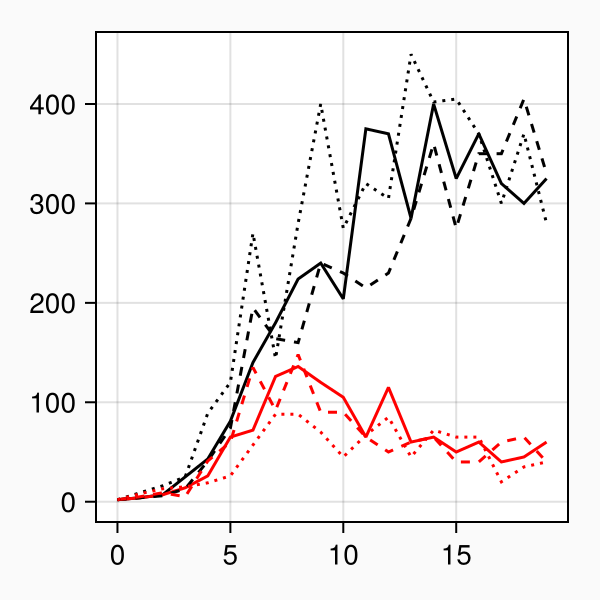

In [3]:
fig = Figure(backgroundcolor = RGBf(0.98, 0.98, 0.98),
    size = (300, 300))
ax = Axis(fig[1,1])
lines!(ax,LinRange(0,length(pac1[:,1])-1,length(pac1[:,1])),pac1[:,1], color=:black, linestyle=:solid)
lines!(ax,LinRange(0,length(pac1[:,2])-1,length(pac1[:,2])),pac1[:,2], color=:red, linestyle=:solid)

lines!(ax,LinRange(0,length(pac2[:,1])-1,length(pac2[:,1])),pac2[:,1], color=:black, linestyle=:dash)
lines!(ax,LinRange(0,length(pac2[:,2])-1,length(pac2[:,2])),pac2[:,2], color=:red, linestyle=:dash)

lines!(ax,LinRange(0,length(pac3[:,1])-1,length(pac3[:,1])),pac3[:,1], color=:black, linestyle=:dot)
lines!(ax,LinRange(0,length(pac3[:,2])-1,length(pac3[:,2])),pac3[:,2], color=:red, linestyle=:dot)


# lines!(ax,0:length(pac2),pac2)
# lines!(ax,0:length(pac3),pac2)
fig

## Fitting the model to the data
Two species Lotka-Volterra competition model can explain the experimentally observed time evolution of population sizes

In [4]:
r1 = 0.7816
r2 = 0.6283
K1 = 559.6860
K2 = 202.4931

202.4931

In [5]:
function twoSpecies_comp!(ndot, n, param, t)
    
    α12, α21 = param

    ndot[1] = r1*n[1]*(K1 - n[1] - α12*n[2])/K1
    ndot[2] = r2*n[2]*(K2 - n[2] - α21*n[1])/K2

end

twoSpecies_comp! (generic function with 1 method)

In [6]:
n0 = [2.0,2.0]          # initial populations
tspan = (0.0,20.0)
params = [2.98; 0.48]
prob = ODEProblem(twoSpecies_comp!, n0, tspan, params)
sol = solve(prob)


retcode: Success
Interpolation: 3rd order Hermite
t: 18-element Vector{Float64}:
  0.0
  0.10743831843544557
  0.42396190153663504
  0.8756365129108504
  1.4173778234475103
  2.080694265678346
  2.850998639926557
  3.738878494869651
  4.749200944962924
  5.911887399671826
  7.387096802774193
  8.812318496390565
 10.90678320554393
 12.136246722535969
 14.158242292923966
 15.99341632103321
 18.60871397928468
 20.0
u: 18-element Vector{Vector{Float64}}:
 [2.0, 2.0]
 [2.172510710516974, 2.1374801704831294]
 [2.770648671180355, 2.5987261236913595]
 [3.9133442470386175, 3.4293958459406597]
 [5.900244657403413, 4.7684624683993375]
 [9.681253636611169, 7.093500571105032]
 [16.93795421847015, 11.098785517374608]
 [31.231964342505933, 18.068378067667712]
 [58.57894259301025, 29.644496904706926]
 [106.04646825752, 46.64245111659662]
 [176.71671639060767, 66.4798313600861]
 [232.61309235845295, 76.32309123606917]
 [284.12501825743385, 76.30722239199173]
 [305.636686663763, 72.42510243128865]
 [337

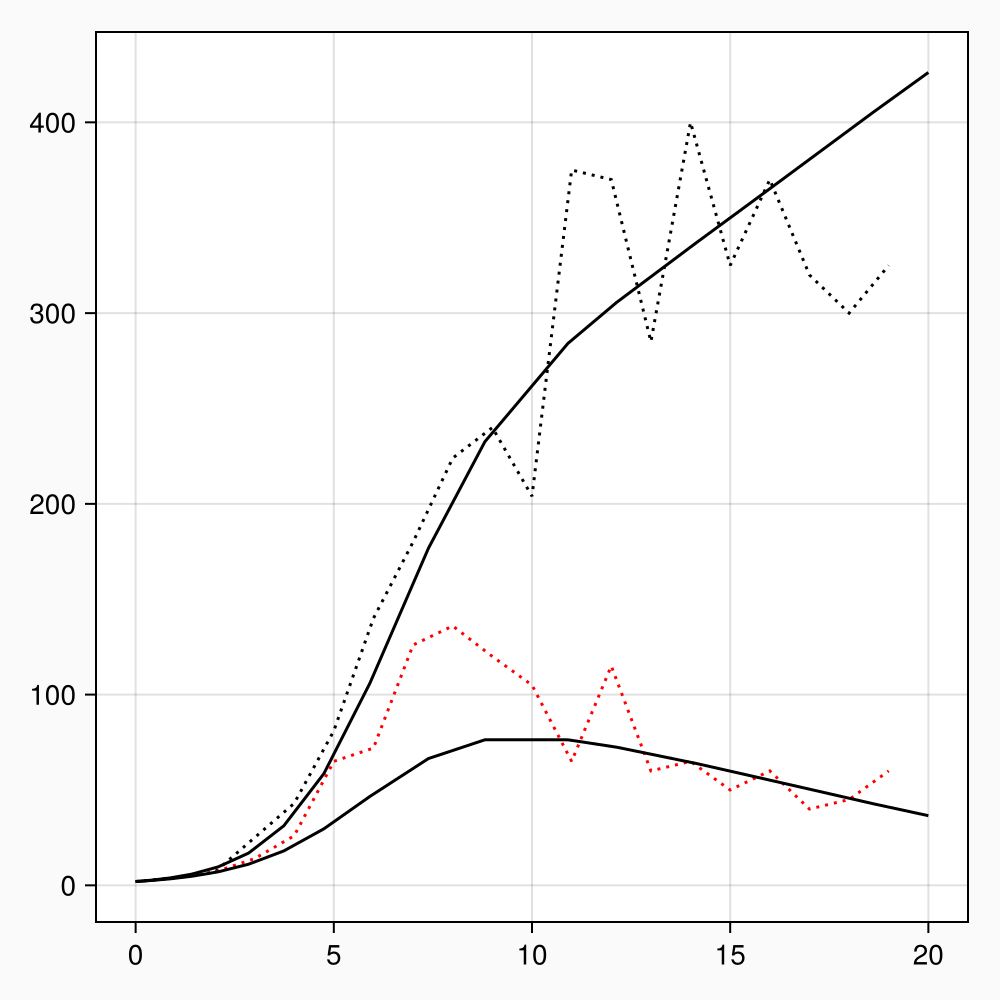

In [7]:
fig = Figure(backgroundcolor = RGBf(0.98, 0.98, 0.98),
    size = (500, 500))
ax = Axis(fig[1,1])

lines!(ax,LinRange(0,length(pac1[:,1])-1,length(pac1[:,1])),pac1[:,1], color=:black, linestyle=:dot)
lines!(ax,LinRange(0,length(pac1[:,2])-1,length(pac1[:,2])),pac1[:,2], color=:red, linestyle=:dot)

# lines!(ax,LinRange(0,length(pac2[:,1])-1,length(pac2[:,1])),pac2[:,1], color=:black, linestyle=:dash)
# lines!(ax,LinRange(0,length(pac2[:,2])-1,length(pac2[:,2])),pac2[:,2], color=:red, linestyle=:dash)

# lines!(ax,LinRange(0,length(pac3[:,1])-1,length(pac3[:,1])),pac3[:,1], color=:black, linestyle=:dot)
# lines!(ax,LinRange(0,length(pac3[:,2])-1,length(pac3[:,2])),pac3[:,2], color=:red, linestyle=:dot)

x = getindex.(sol.u, 1)
y = getindex.(sol.u, 2)
lines!(ax, sol.t,x,color=:black)
lines!(ax, sol.t,y,color=:black)
fig

In [8]:
data_times = 1:20
ind_pac = 1

1

In [9]:
function loss(params)

    α12,α21= params

    prob = ODEProblem(twoSpecies_comp!,n0,tspan,params)
    sol = solve(prob, saveat=data_times)

    pred1 = sol[1,:]
    pred2 = sol[2,:]

    tot_err = 0

    pac = pac_reps[ind_pac]
    obs1 = pac[:,1]
    obs2 = pac[:,2]    
    tot_err = sum((pred1 .- obs1).^2) + sum((pred2 .- obs2).^2)
    
    return tot_err
end

loss (generic function with 1 method)

In [10]:
initial_guess = [0.1,0.1]
ind_pac = 1
result = optimize(loss, initial_guess)

best_params = Optim.minimizer(result)

2-element Vector{Float64}:
 2.79163422788699
 0.4177304447323494

In [11]:
K2/K1

0.36179768655996397

In [12]:
best_alpha1 = 0
best_alpha2 = 0
for ind_p in 1:3
    println(ind_pac)
    ind_pac = ind_p
    result = optimize(loss, initial_guess)
    best_params = Optim.minimizer(result)
    best_alpha1 += best_params[1]/3
    best_alpha2 += best_params[2]/3
end


1
1
2


In [13]:
α = [best_alpha1 ; best_alpha2]

2-element Vector{Float64}:
 2.9243023044906313
 0.446313046279907

In [14]:
n0 = [10.0,10.0]          # initial populations
tspan = (0.0,20.0)

params = [1.0, 0.8, 100.0, 80.0, 0.5, 1.5]

prob = ODEProblem(twoSpecies_comp!, n0, tspan, params)

sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 22-element Vector{Float64}:
  0.0
  0.10836639362614536
  0.43349909976640033
  0.9013185829527293
  1.4650424462852194
  2.163623150057579
  2.988377015364505
  3.9628318080935685
  5.063467312373504
  6.272372351503928
  7.619753144660977
  8.826216394324668
 10.430704988911835
 11.486381090783995
 12.738124088227867
 13.850677006022115
 15.016547753604181
 16.140346722425253
 17.277213469807823
 18.40147218185948
 19.531349461681106
 20.0
u: 22-element Vector{Vector{Float64}}:
 [10.0, 10.0]
 [10.849796583914157, 10.637657800655038]
 [13.83761708933316, 12.768583543558805]
 [19.545223120551537, 16.454496542155567]
 [29.350221591231225, 21.92451127225204]
 [47.614242618213055, 30.10738720332203]
 [80.99247079364639, 40.58059882744976]
 [140.53469864225542, 50.079153154150895]
 [231.22339637721737, 50.70153846387338]
 [339.9086819931497, 38.73345227600954]
 [439.8640160015645, 21.4249510793211]
 [497.4640934155144, 10.523120201231393

In [15]:
rangeK1 = 0.1*K1:0.1*K1:1.2*K1
rangeK2 = 0.1*K2:0.1*K2:1.2*K2

# initial conditions along the four edges of the rectangle
n0s_1 = hcat([[n1, 0.1*K2] for n1 in rangeK1]...)   # bottom edge
n0s_2 = hcat([[n1, 1.2*K2] for n1 in rangeK1]...)   # top edge
n0s_3 = hcat([[0.1*K1, n2] for n2 in rangeK2]...)   # left edge
n0s_4 = hcat([[1.2*K1, n2] for n2 in rangeK2]...)   # right edge

# combine them
n0s = hcat(n0s_1, n0s_2, n0s_3, n0s_4)

println(n0s)
length(n0s[1,:])

[55.96860000000001 111.93720000000002 167.90580000000003 223.87440000000004 279.8430000000001 335.8116000000001 391.78020000000004 447.7488000000001 503.7174000000001 559.6860000000001 615.6546000000002 55.96860000000001 111.93720000000002 167.90580000000003 223.87440000000004 279.8430000000001 335.8116000000001 391.78020000000004 447.7488000000001 503.7174000000001 559.6860000000001 615.6546000000002 55.96860000000001 55.96860000000001 55.96860000000001 55.96860000000001 55.96860000000001 55.96860000000001 55.96860000000001 55.96860000000001 55.96860000000001 55.96860000000001 55.96860000000001 55.96860000000001 671.6232 671.6232 671.6232 671.6232 671.6232 671.6232 671.6232 671.6232 671.6232 671.6232 671.6232 671.6232; 20.24931 20.24931 20.24931 20.24931 20.24931 20.24931 20.24931 20.24931 20.24931 20.24931 20.24931 242.99172 242.99172 242.99172 242.99172 242.99172 242.99172 242.99172 242.99172 242.99172 242.99172 242.99172 20.24931 40.49862 60.74793 80.99724 101.24655 121.49586 141.7

46

In [16]:
function prob_func(prob, i, repeat)
    remake(prob, u0=n0s[:,i])
end

prob_func (generic function with 1 method)

In [17]:
function access_sol(sol, ax, i)
    x = getindex.(sol[i].u, 1)
    y = getindex.(sol[i].u, 2)
    lines!(ax, x, y, color=:black,alpha=0.7)
end

access_sol (generic function with 1 method)

In [18]:
function flow_draw(ax, f!, param, time_end)
    
      tspan = (0.0,time_end)
      n0 = n0s[:,1]         # initial populations
      prob = ODEProblem(f!, n0, tspan, param, reltol=1e-8, abstol=1e-8)

      ensemble_prob = EnsembleProblem(prob, prob_func=prob_func)
      sol = solve(ensemble_prob, Tsit5(), trajectories=length(n0s[1,:]))

      map(i->access_sol(sol, ax, i), 1:length(n0s[1,:]))
      
  end


flow_draw (generic function with 1 method)

In [19]:
α = best_params
K2/K1

0.36179768655996397

In [20]:
fig = Figure(backgroundcolor = RGBf(0.98, 0.98, 0.98),
    size = (500, 500))
ax = Axis(fig[1,1])

flow_draw(ax, twoSpecies_comp!, α, 20)

46-element Vector{Lines{Tuple{Vector{Point{2, Float64}}}}}:
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 ⋮
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float64}}}}
 Lines{Tuple{Vector{Point{2, Float6

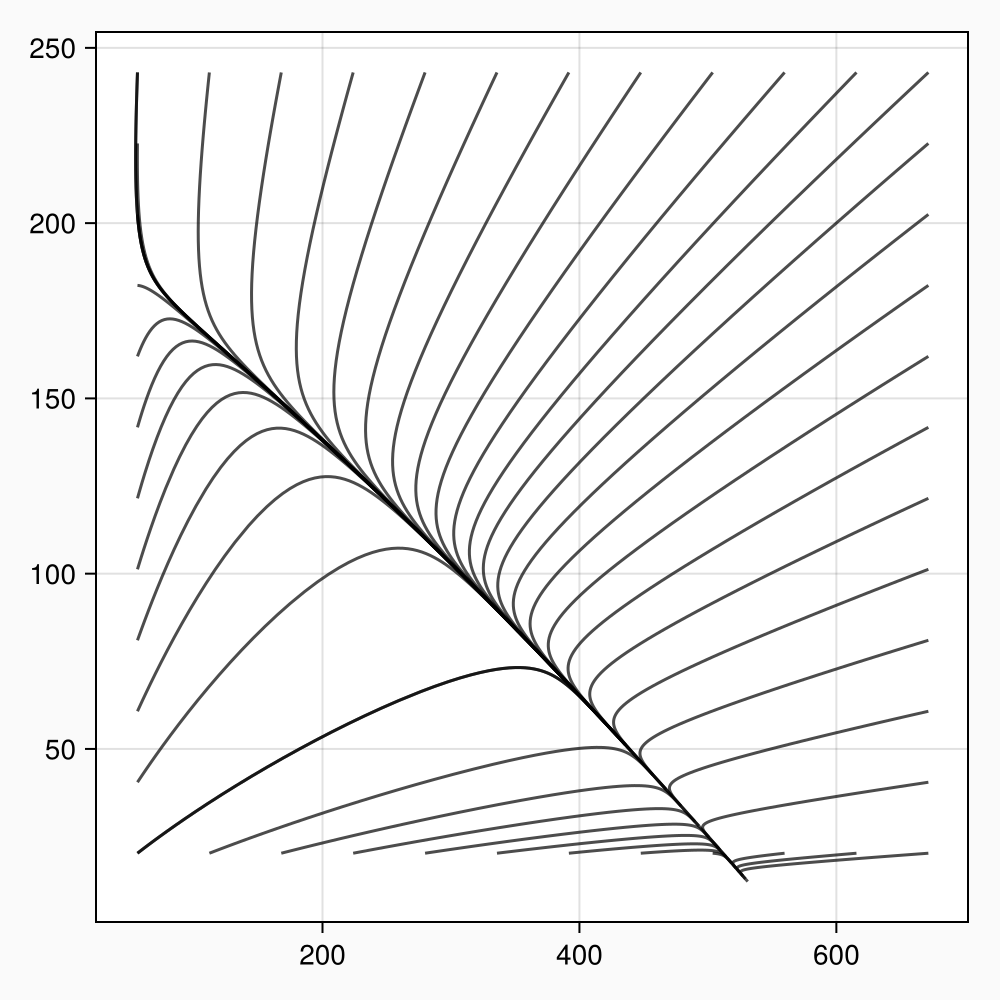

In [21]:
fig

## Fixed points/Equilibrium states

$$
\begin{split}
0 &= r_{1}N_{1}(K_{1}-N_{1}-\alpha_{12}N_{2})/K_{1}\\
0 &= r_{2}N_{2}(K_{2}-N_{2}-\alpha_{21}N_{1})/K_{2}
\end{split}
$$

1. $N_{1}$ = 0 and $N_2$ = 0.
2. $N_{1}$ = $K_1$ and $N_2$ = 0.
3. $N_{1}$ = 0 and $N_2$ = $K_2$.
4. they both satisfy
   $$
   \begin{split}
   0 &= K_1 - N_1 - \alpha_{12}N_2\\
   0 &= K_2 - N_2 - \alpha_{21}N_1
   \end{split}
   $$

### "Invasion-when-rare" condition to analyze the stability of equilibrium 2. and 3.

We begin with a species-2 alone ($N_2 = K_2$) and introduce a small amount of species-1 ($N_1 \approx 0$ ), can it increase in size?

If the answer is yes, then species-2 alone equilibrium (N_1 = K_1 & N_2 = 0) is unstable.

To say that species-2 alone equilibrium is stable, on the other hand, apart from the inability of species-1 to increase in size when it is rare, the species-2 should also decrease when it is rare. That is, the habitat is so poor that species-2 is unable to maintain a breeding population.

We can translate all these conditions in terms of the equations above. From,

$$
\begin{split}
\frac{dN1}{dt} = \frac{r_{1}N_{1}(K_{1}-N_{1}-\alpha_{12}N_{2})}{K_1}
\end{split}
$$

We want this term on the right to be positive for N1 to increase. Specifically here, we want it to be positive when $N_{1}$ is close to zero and $N_{2}=K_2$.  $N_1$ and $K_1$ are positive numbers. The term in the parenthesis must be positive. When $N_{1}$ is close to zero and $N_{2}=K_2$, it can be rewritten as follows,

$$
K_{1} - \alpha_{12}K_{2}
$$

This term must be positive for $N_1$ to increase. Or, equivalently, $\alpha_{12} < \frac{K_1}{K_2}$.

A similar condition for species-2 can be derived. So, species-2 can invade-when-rare when $\alpha_{21} < \frac{K_2}{K_1}$.

Given this condition for the stability of equilibrium 2. and 3., we can imagine the following scenarios.


### Case 1: Species-1 can invade-when-rare and species-2 can't invade-when-rare

$$
\begin{split}
\alpha_{12} < \frac{K_1}{K_2}\\
\alpha_{21} > \frac{K_2}{K_1}
\end{split}
$$



In [22]:
# K1 = 559.6860
# K2 = 202.4931
# K1/K2 = 2.763975661392907
# K2/K1 = 0.36179768655996397
α = [2.5; 0.48]

2-element Vector{Float64}:
 2.5
 0.48

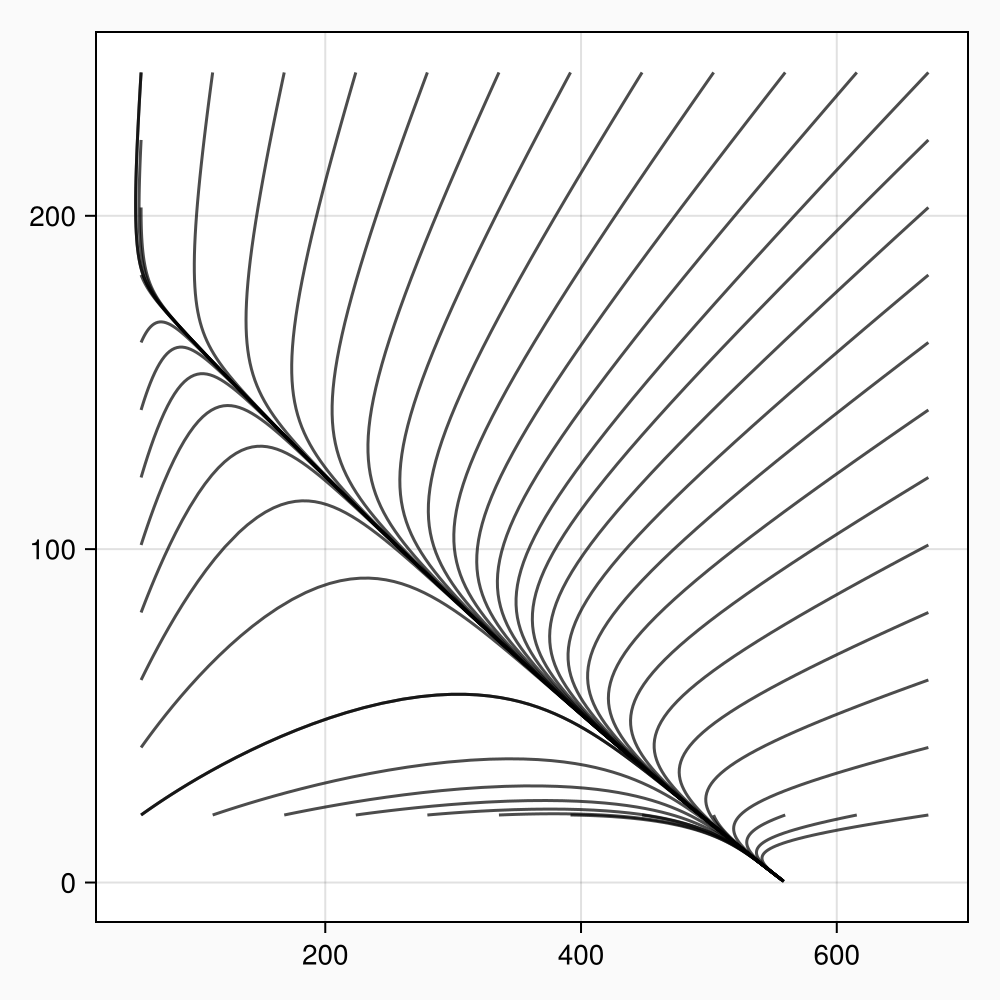

In [23]:
fig = Figure(backgroundcolor = RGBf(0.98, 0.98, 0.98),
    size = (500, 500))
ax = Axis(fig[1,1])

flow_draw(ax, twoSpecies_comp!, α, 20)
fig

### Case 2: Species-2 can invade-when-rare and species-1 can't invade-when-rare

$$
\begin{split}
\alpha_{12} > \frac{K_1}{K_2}\\
\alpha_{21} < \frac{K_2}{K_1}
\end{split}
$$



In [24]:
# K1 = 559.6860
# K2 = 202.4931
# K1/K2 = 2.763975661392907
# K2/K1 = 0.36179768655996397
α = [2.8; 0.3]

2-element Vector{Float64}:
 2.8
 0.3

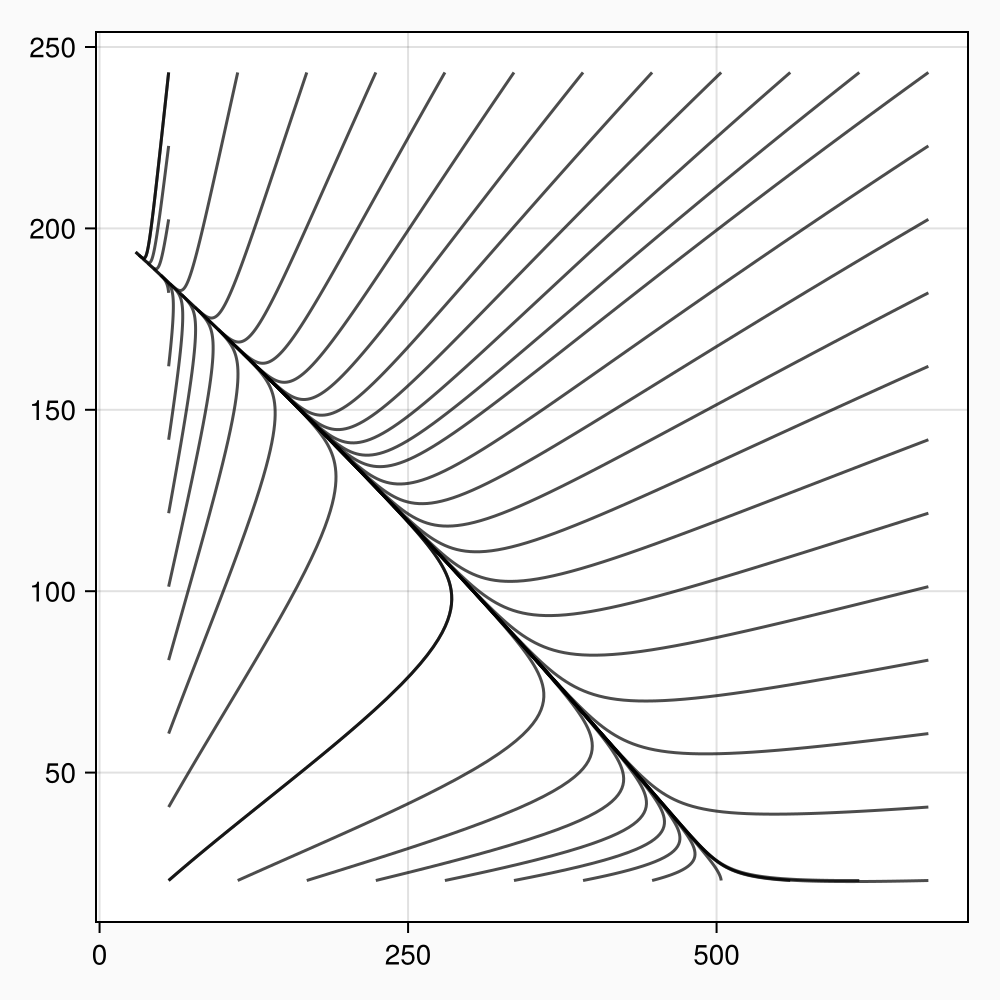

In [25]:
fig = Figure(backgroundcolor = RGBf(0.98, 0.98, 0.98),
    size = (500, 500))
ax = Axis(fig[1,1])

flow_draw(ax, twoSpecies_comp!, α, 20)
fig

### Case 3: Species-2 can invade-when-rare and species-1 can invade-when-rare

$$
\begin{split}
\alpha_{12} < \frac{K_1}{K_2}\\
\alpha_{21} < \frac{K_2}{K_1}
\end{split}
$$


In [26]:
# K1 = 559.6860
# K2 = 202.4931
# K1/K2 = 2.763975661392907
# K2/K1 = 0.36179768655996397
α = [2.5; 0.3]

2-element Vector{Float64}:
 2.5
 0.3

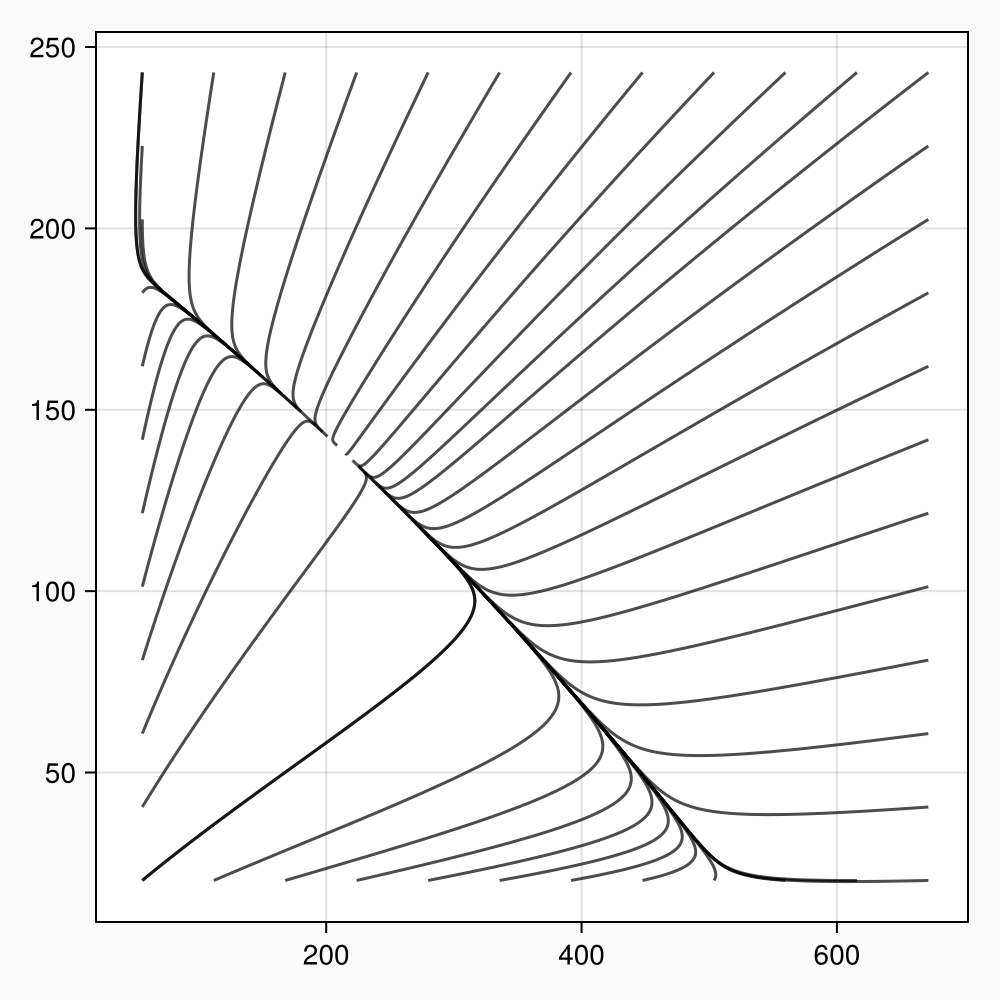

In [27]:
fig = Figure(backgroundcolor = RGBf(0.98, 0.98, 0.98),
    size = (500, 500))
ax = Axis(fig[1,1])

flow_draw(ax, twoSpecies_comp!, α, 20)
fig

### Case 4: Species-2 can't invade-when-rare and species-1 can't invade-when-rare

$$
\begin{split}
\alpha_{12} > \frac{K_1}{K_2}\\
\alpha_{21} > \frac{K_2}{K_1}
\end{split}
$$


In [28]:
# K1 = 559.6860
# K2 = 202.4931
# K1/K2 = 2.763975661392907
# K2/K1 = 0.36179768655996397
α = [2.8; 0.38]

2-element Vector{Float64}:
 2.8
 0.38

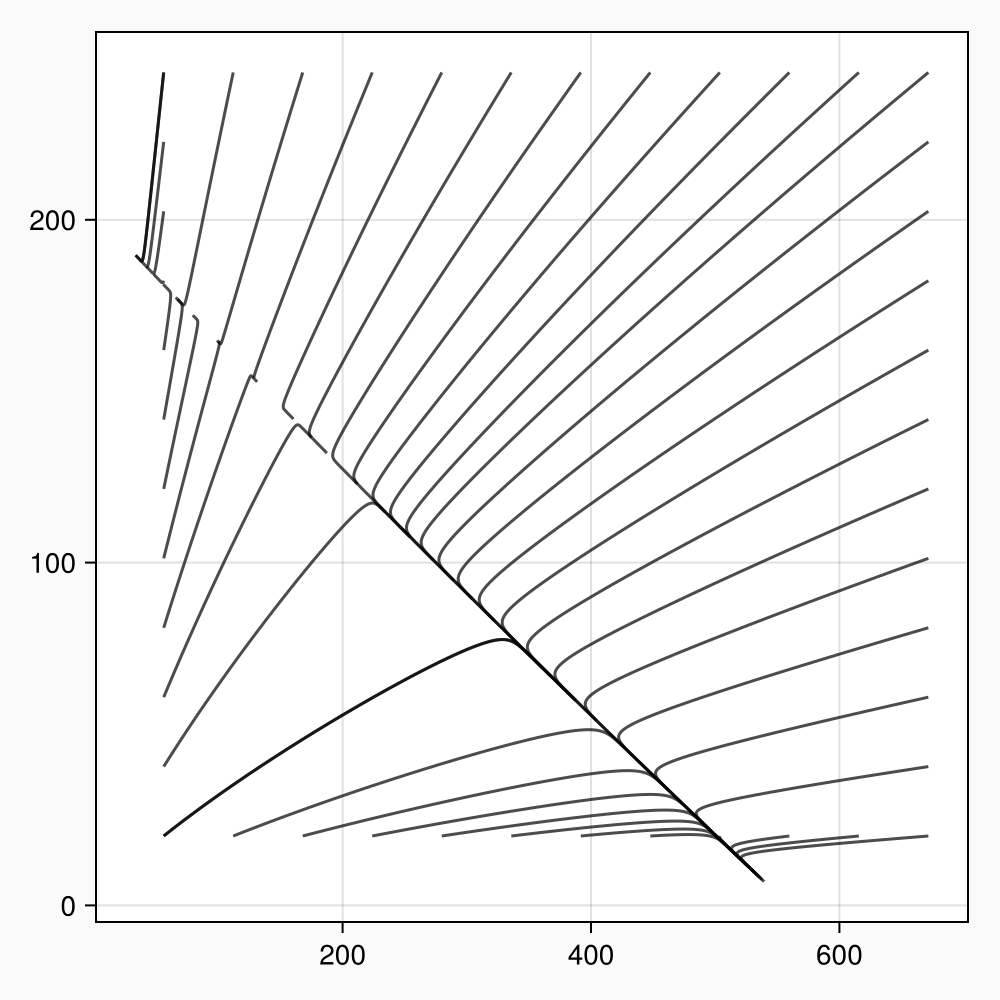

In [29]:
fig = Figure(backgroundcolor = RGBf(0.98, 0.98, 0.98),
    size = (500, 500))
ax = Axis(fig[1,1])

flow_draw(ax, twoSpecies_comp!, α, 30)
fig

## Stability of multi-species equilibrium points



In [30]:
@syms N1 N2 r1 r2 K1 K2 α12 α21

dN1 = r1*N1*(K1-N1-α12*N2)/K1
dN2 = r2*N2*(K2-N2-α21*N1)/K2
[dN1 ; dN2]

2-element Vector{Sym{PyCall.PyObject}}:
 N1*r1*(K1 - N1 - N2*α12)/K1
 N2*r2*(K2 - N1*α21 - N2)/K2

In [31]:
dNs = [dN1, dN2]
Ns = [N1, N2]

2-element Vector{Sym{PyCall.PyObject}}:
 N₁
 N₂

In [32]:
equilibria = solve(dNs, Ns)

4-element Vector{Tuple{Sym{PyCall.PyObject}, Sym{PyCall.PyObject}}}:
 (0, 0)
 (0, K2)
 (K1, 0)
 (-(K1 - K2*α12)/(α12*α21 - 1), (K1*α21 - K2)/(α12*α21 - 1))

In [33]:
Jac = Matrix([
    diff(dN1, N1)  diff(dN1, N2);
    diff(dN2, N1)  diff(dN2, N2)
])

2×2 Matrix{Sym{PyCall.PyObject}}:
 -N1*r1/K1 + r1*(K1 - N1 - N2*α12)/K1                         -N1*r1*α12/K1
                        -N2*r2*α21/K2  -N2*r2/K2 + r2*(K2 - N1*α21 - N2)/K2

In [34]:
l_jeval = []
for eq in equilibria
    println("Equilibrium: ", eq)
    sub_dict = Dict(N1 => eq[1], N2 => eq[2])
    J_eval = Jac.subs(sub_dict)
    push!(l_jeval, J_eval)
end

Equilibrium: (0, 0)
Equilibrium: (0, K2)
Equilibrium: (K1, 0)
Equilibrium: (-(K1 - K2*α12)/(α12*α21 - 1), (K1*α21 - K2)/(α12*α21 - 1))


In [35]:
l_jeval[1]

2×2 Matrix{Sym{PyCall.PyObject}}:
 r₁   0
  0  r₂

In [36]:
l_jeval[2]

2×2 Matrix{Sym{PyCall.PyObject}}:
 r1*(K1 - K2*α12)/K1    0
             -r₂⋅α₂₁  -r₂

In [37]:
l_jeval[3]

2×2 Matrix{Sym{PyCall.PyObject}}:
 -r₁               -r₁⋅α₁₂
   0  r2*(-K1*α21 + K2)/K2

In [38]:
l_jeval[4]

2×2 Matrix{Sym{PyCall.PyObject}}:
 r1*(K1 - K2*α12)/(K1*(α12*α21 - 1)) + r1*(K1 - α12*(K1*α21 - K2)/(α12*α21 - 1) + (K1 - K2*α12)/(α12*α21 - 1))/K1  …                                                                            r1*α12*(K1 - K2*α12)/(K1*(α12*α21 - 1))
                                                                         -r2*α21*(K1*α21 - K2)/(K2*(α12*α21 - 1))     -r2*(K1*α21 - K2)/(K2*(α12*α21 - 1)) + r2*(K2 + α21*(K1 - K2*α12)/(α12*α21 - 1) - (K1*α21 - K2)/(α12*α21 - 1))/K2

In [39]:

function plot_eigs(param_dict, eq_number)

jac_eval = l_jeval[eq_number].subs(param_dict)
eigs = eigen(jac_eval).values
# Define the endpoint
point1 = Point2f(eigs[1],0)
point2 = Point2f(eigs[2],0)
fig = Figure()
ax = Axis(fig[1, 1], limits = (-0.5, 0.1, -.1, .1), aspect = DataAspect())

# Plot arrow from (0,0) to 'point'
arrows2d!(ax, [Point2f(0,0)], [Vec2f(point1)]; 
        lengthscale=1,color=:blue, alpha=0.4) # :tail ensures start at (0,0)

arrows2d!(ax, [Point2f(0,0)], [Vec2f(point2)]; 
        lengthscale=1,color=:green, alpha=0.4) # :tail ensures start at (0,0)

display(fig)
end
    

plot_eigs (generic function with 1 method)

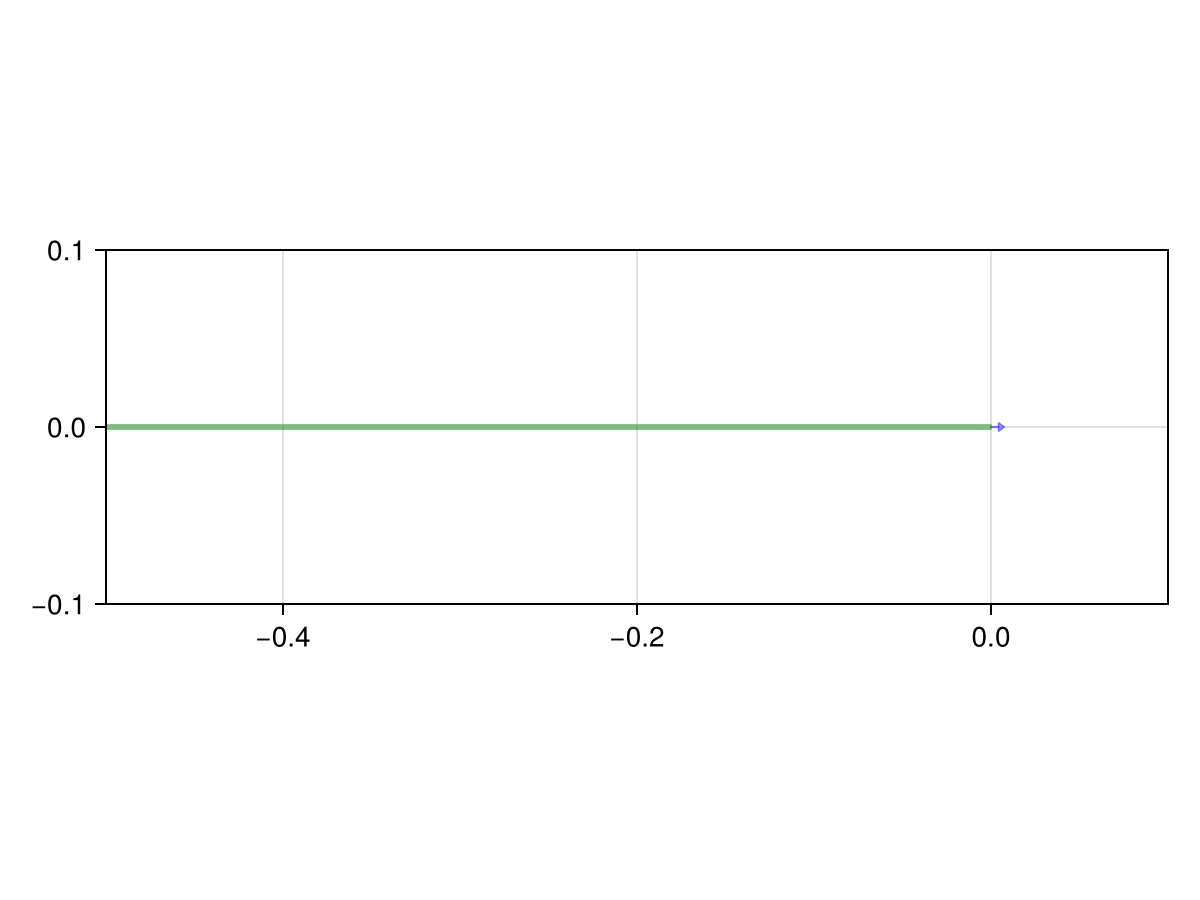

CairoMakie.Screen{IMAGE}


In [40]:
param_dict = Dict(r1 => 0.7816 , r2 => 0.6283, K1 => 559.6860, K2 => 202.4931, α12 => 2.8,  α21 => 0.38)

plot_eigs(param_dict, 4)